# NYC Airbnb Market Intelligence: Pricing, Demand & Availability EDA

## Project Objective
This project converts raw Airbnb listing data into business-ready insights for pricing strategy, market positioning, host performance, and neighborhood-level opportunity analysis.

The goal is not just to create charts, but to answer practical business questions a marketplace, revenue, or operations team would care about.

## Business Questions
1. **Market Supply:** Which boroughs, neighborhoods, and room types have the highest listing concentration?
2. **Pricing Strategy:** How do prices vary by borough, neighborhood, and room type?
3. **Revenue Opportunity:** Which listing segments show strong price and availability potential?
4. **Customer Demand Signals:** How do reviews, ratings, and review frequency vary across listing types?
5. **Operational Policy:** How do minimum-night rules and availability patterns affect guest accessibility?
6. **Host Strategy:** Are listings concentrated among individual hosts or professional/multi-listing hosts?
7. **Geographic Patterns:** Where are high-value and high-availability listings located?

## Dataset Context
The original notebook shows the dataset contains **20,770 listings and 22 columns**, including listing details, host details, neighborhood, price, availability, reviews, room type, and location coordinates.

> Note: This notebook assumes the dataset file is named `datasets.csv` and is stored in the same folder as this notebook. Update `DATA_PATH` if your file name is different.

## 1. Import Libraries and Set Up Notebook
We will use Pandas and NumPy for analysis, Matplotlib and Seaborn for visualization, and a few helper functions to keep the workflow clean and reusable.

In [1]:
# Core data manipulation
from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

DATA_PATH = Path('datasets.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

## 2. Load the Dataset
This step loads the raw CSV and validates that the file exists before analysis begins. This makes the notebook easier for recruiters or reviewers to run locally.

In [2]:
if not DATA_PATH.exists():
    available_csvs = list(Path('.').glob('*.csv'))
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place datasets.csv in this folder or update DATA_PATH. "
        f"Available CSV files: {[str(file) for file in available_csvs]}"
    )

raw_df = pd.read_csv(DATA_PATH, encoding_errors='ignore')
df = raw_df.copy()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
df.head()

Rows: 20,770
Columns: 22


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,"1,312,228.00",Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.68,-73.96,Private room,55.00,30.00,3.00,20/12/15,0.03,1.00,0.00,0.00,No License,5,1,1,Not specified
1,"45,277,537.00",Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.77,-73.99,Entire home/apt,144.00,30.00,9.00,01/05/23,0.24,139.00,364.00,2.00,No License,4.67,2,1,1
2,"971,000,000,000,000,000.00",Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.75,-73.99,Entire home/apt,187.00,2.00,6.00,18/12/23,1.67,1.00,343.00,6.00,Exempt,4.17,1,2,1
3,"3,857,863.00",Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.84,-73.94,Private room,120.00,30.00,156.00,17/09/23,1.38,2.00,363.00,12.00,No License,4.64,1,1,1
4,"40,896,611.00",Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.75,-73.98,Entire home/apt,85.00,30.00,11.00,03/12/23,0.24,133.00,335.00,3.00,No License,4.91,Studio,1,1


## 3. Initial Data Understanding
Before cleaning, we review structure, data types, missing values, duplicates, and summary statistics. This gives a clear baseline and prevents blind cleaning decisions.

In [3]:
# Review dataset structure
print('Dataset information:')
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  object 
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  object 
 4   neighbourhood_group             20770 non-null  object 
 5   neighbourhood                   20763 non-null  object 
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  object 
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review

In [4]:
# High-level numeric summary
numeric_summary = df.describe(include=[np.number]).T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
id,"20,770.00","303,385,844,987,444,096.00","390,122,084,199,060,480.00","2,595.00","27,072,602.75","49,928,523.50","722,000,000,000,000,000.00","1,050,000,000,000,000,000.00"
host_id,"20,770.00","174,904,903.02","172,565,669.39","1,678.00","20,411,843.75","108,699,045.00","314,399,689.50","550,403,525.00"
latitude,"20,763.00",40.73,0.06,40.50,40.68,40.72,40.76,40.91
longitude,"20,763.00",-73.94,0.06,-74.25,-73.98,-73.95,-73.92,-73.71
price,"20,736.00",187.71,"1,023.25",10.00,80.00,125.00,199.00,"100,000.00"
minimum_nights,"20,763.00",28.56,33.53,1.00,30.00,30.00,30.00,"1,250.00"
number_of_reviews,"20,763.00",42.61,73.52,1.00,4.00,14.00,49.00,"1,865.00"
reviews_per_month,"20,763.00",1.26,1.90,0.01,0.21,0.65,1.80,75.49
calculated_host_listings_count,"20,763.00",18.87,70.92,1.00,1.00,2.00,5.00,713.00
availability_365,"20,763.00",206.07,135.08,0.00,87.00,215.00,353.00,365.00


In [5]:
# High-level categorical summary
categorical_summary = df.describe(include='object').T
categorical_summary

,count,unique,top,freq
name,20770,9836,Rental unit in New York · 1 bedroom · 1 bed · ...,409
host_name,20770,5815,Jeniffer,187
neighbourhood_group,20770,5,Manhattan,8050
neighbourhood,20763,221,Bedford-Stuyvesant,1583
room_type,20763,4,Entire home/apt,11555
last_review,20763,1878,04/09/23,326
license,20770,879,No License,17579
rating,20770,162,No rating,3595
bedrooms,20770,12,1,13445
baths,20770,17,1,17026


In [6]:
# Missing value audit
missing_summary = (
    df.isna().sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .query('missing_count > 0')
      .sort_values('missing_count', ascending=False)
)

missing_summary

,missing_count,missing_pct
price,34,0.16
neighbourhood,7,0.03
latitude,7,0.03
longitude,7,0.03
room_type,7,0.03
minimum_nights,7,0.03
number_of_reviews,7,0.03
last_review,7,0.03
reviews_per_month,7,0.03
calculated_host_listings_count,7,0.03


In [7]:
# Duplicate audit
duplicate_count = df.duplicated().sum()
print(f'Duplicate rows: {duplicate_count:,}')

Duplicate rows: 12


## 4. Data Cleaning Strategy
The original notebook dropped all missing rows. For an industry-level EDA, we use a more controlled approach:

- Standardize column names.
- Remove duplicate rows.
- Convert IDs to strings so they are not treated as numeric measures.
- Parse date columns.
- Convert numeric-like text fields such as rating, bedrooms, and baths.
- Remove records missing critical analysis fields such as price, room type, borough, and coordinates.
- Treat extreme price outliers separately instead of deleting data without explanation.

In [8]:
# Standardize column names for easier analysis
clean_df = df.copy()
clean_df.columns = (
    clean_df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_', regex=False)
)

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Convert ID columns to string/object because they are identifiers, not numeric metrics
for col in ['id', 'host_id']:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].astype('Int64').astype(str)

# Parse date fields
if 'last_review' in clean_df.columns:
    clean_df['last_review'] = pd.to_datetime(clean_df['last_review'], errors='coerce', dayfirst=True)

# Helper function to extract numeric value from text-based fields
def extract_first_number(value):
    # Extract the first numeric value from a string. Returns NaN when no number exists.
    if pd.isna(value):
        return np.nan
    match = re.search(r'\d+\.?\d*', str(value))
    return float(match.group()) if match else np.nan

# Convert numeric-like columns stored as text
for col in ['rating', 'bedrooms', 'baths']:
    if col in clean_df.columns:
        clean_df[f'{col}_numeric'] = clean_df[col].apply(extract_first_number)

# Convert expected numeric columns safely
numeric_cols = [
    'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm',
    'latitude', 'longitude', 'beds'
]
for col in numeric_cols:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

# Keep rows required for pricing, location, and segmentation analysis
critical_cols = ['price', 'neighbourhood_group', 'neighbourhood', 'room_type', 'latitude', 'longitude']
existing_critical_cols = [col for col in critical_cols if col in clean_df.columns]
clean_df = clean_df.dropna(subset=existing_critical_cols)

# Remove impossible or non-business-useful prices
clean_df = clean_df[clean_df['price'] > 0]

print(f'Rows after cleaning: {clean_df.shape[0]:,}')
print(f'Columns after cleaning: {clean_df.shape[1]:,}')

Rows after cleaning: 20,724
Columns after cleaning: 25


### Price Outlier Treatment
Airbnb prices are typically right-skewed. Instead of removing all outliers permanently, we create a focused analysis dataframe using an IQR-based cap. This keeps the raw cleaned data available while making charts more interpretable.

In [9]:
# IQR-based price threshold for focused EDA visuals
q1 = clean_df['price'].quantile(0.25)
q3 = clean_df['price'].quantile(0.75)
iqr = q3 - q1
upper_price_limit = q3 + 1.5 * iqr

# Keep a business-friendly minimum cap as an additional guardrail
focused_df = clean_df[clean_df['price'] <= upper_price_limit].copy()

print(f'Q1 price: ${q1:,.0f}')
print(f'Q3 price: ${q3:,.0f}')
print(f'IQR upper limit: ${upper_price_limit:,.0f}')
print(f'Focused analysis rows: {focused_df.shape[0]:,}')
print(f'Removed extreme price records from focused visuals: {clean_df.shape[0] - focused_df.shape[0]:,}')

Q1 price: $80
Q3 price: $199
IQR upper limit: $378
Focused analysis rows: 19,342
Removed extreme price records from focused visuals: 1,382


## 5. Feature Engineering
New fields help translate raw listing data into business signals:

- **price_per_bed:** Helps compare relative value across listings with different bed counts.
- **availability_bucket:** Groups listings by yearly availability.
- **host_portfolio_type:** Distinguishes individual hosts from multi-listing/professional hosts.
- **estimated_annual_revenue:** A simple opportunity proxy based on price and availability.
- **review_recency_days:** Indicates how recently a listing received a review.

In [10]:
# Avoid divide-by-zero issues for price per bed
if 'beds' in focused_df.columns:
    focused_df['price_per_bed'] = np.where(
        focused_df['beds'] > 0,
        focused_df['price'] / focused_df['beds'],
        np.nan
    )

# Availability bucket for easier business interpretation
if 'availability_365' in focused_df.columns:
    focused_df['availability_bucket'] = pd.cut(
        focused_df['availability_365'],
        bins=[-1, 0, 90, 180, 365],
        labels=['Unavailable', 'Low availability', 'Medium availability', 'High availability']
    )

# Minimum-night policy segment
if 'minimum_nights' in focused_df.columns:
    focused_df['stay_policy'] = pd.cut(
        focused_df['minimum_nights'],
        bins=[0, 2, 7, 30, np.inf],
        labels=['Short stay friendly', 'Weekly stay', 'Monthly stay', 'Long-term only']
    )

# Host portfolio type based on listing count
if 'calculated_host_listings_count' in focused_df.columns:
    focused_df['host_portfolio_type'] = pd.cut(
        focused_df['calculated_host_listings_count'],
        bins=[0, 1, 5, 20, np.inf],
        labels=['Single-listing host', 'Small portfolio host', 'Medium portfolio host', 'Large portfolio host']
    )

# Revenue proxy: useful for ranking opportunity, not a true revenue estimate
if {'price', 'availability_365'}.issubset(focused_df.columns):
    focused_df['estimated_annual_revenue_proxy'] = focused_df['price'] * focused_df['availability_365']

# Review recency
if 'last_review' in focused_df.columns and focused_df['last_review'].notna().any():
    latest_review_date = focused_df['last_review'].max()
    focused_df['review_recency_days'] = (latest_review_date - focused_df['last_review']).dt.days

focused_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths,rating_numeric,bedrooms_numeric,baths_numeric,price_per_bed,availability_bucket,stay_policy,host_portfolio_type,estimated_annual_revenue_proxy,review_recency_days
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.68,-73.96,Private room,55.00,30.00,3.00,2015-12-20,0.03,1.00,0.00,0.00,No License,5,1,1,Not specified,5.00,1.00,NaN,55.00,Unavailable,Monthly stay,Single-listing host,0.00,2938
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.77,-73.99,Entire home/apt,144.00,30.00,9.00,2023-05-01,0.24,139.00,364.00,2.00,No License,4.67,2,1,1,4.67,2.00,1.00,144.00,High availability,Monthly stay,Large portfolio host,"52,416.00",249
2,971000000000000000,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.75,-73.99,Entire home/apt,187.00,2.00,6.00,2023-12-18,1.67,1.00,343.00,6.00,Exempt,4.17,1,2,1,4.17,1.00,1.00,93.50,High availability,Short stay friendly,Single-listing host,"64,141.00",18
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.84,-73.94,Private room,120.00,30.00,156.00,2023-09-17,1.38,2.00,363.00,12.00,No License,4.64,1,1,1,4.64,1.00,1.00,120.00,High availability,Monthly stay,Small portfolio host,"43,560.00",110
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.75,-73.98,Entire home/apt,85.00,30.00,11.00,2023-12-03,0.24,133.00,335.00,3.00,No License,4.91,Studio,1,1,4.91,NaN,1.00,85.00,High availability,Monthly stay,Large portfolio host,"28,475.00",33


## 6. Executive KPI Snapshot
This section creates a compact business summary that can be used in the README, report, or portfolio case study.

In [11]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total listings analyzed',
        'Median nightly price',
        'Average nightly price',
        'Median availability days',
        'Average reviews per listing',
        'Unique neighborhoods',
        'Unique hosts'
    ],
    'Value': [
        f"{len(focused_df):,}",
        f"${focused_df['price'].median():,.0f}",
        f"${focused_df['price'].mean():,.0f}",
        f"{focused_df['availability_365'].median():,.0f}" if 'availability_365' in focused_df.columns else 'N/A',
        f"{focused_df['number_of_reviews'].mean():,.1f}" if 'number_of_reviews' in focused_df.columns else 'N/A',
        f"{focused_df['neighbourhood'].nunique():,}" if 'neighbourhood' in focused_df.columns else 'N/A',
        f"{focused_df['host_id'].nunique():,}" if 'host_id' in focused_df.columns else 'N/A'
    ]
})

kpi_summary

,Metric,Value
0,Total listings analyzed,"19,342"
1,Median nightly price,$120
2,Average nightly price,$136
3,Median availability days,209
4,Average reviews per listing,43.6
5,Unique neighborhoods,221
6,Unique hosts,"11,620"


## 7. Business Question 1: Where is Airbnb supply concentrated?
This helps identify the most competitive boroughs and the types of inventory available to guests.

In [12]:
borough_supply = (
    focused_df['neighbourhood_group']
      .value_counts()
      .rename_axis('neighbourhood_group')
      .reset_index(name='listing_count')
)

borough_supply['listing_share_pct'] = (borough_supply['listing_count'] / borough_supply['listing_count'].sum() * 100).round(2)
borough_supply

,neighbourhood_group,listing_count,listing_share_pct
0,Brooklyn,7295,37.72
1,Manhattan,7157,37.00
2,Queens,3670,18.97
3,Bronx,934,4.83
4,Staten Island,286,1.48


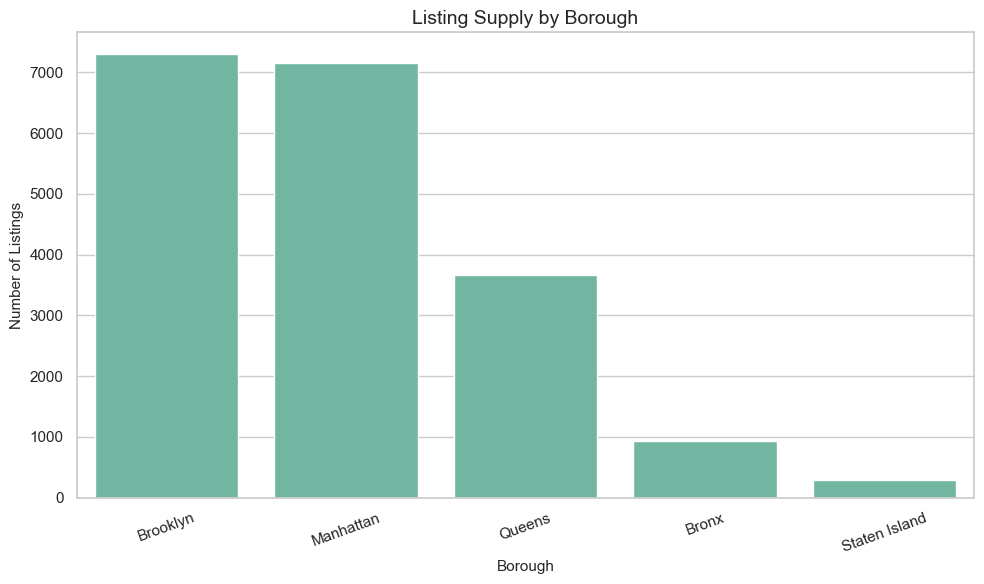

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=borough_supply, x='neighbourhood_group', y='listing_count')
plt.title('Listing Supply by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

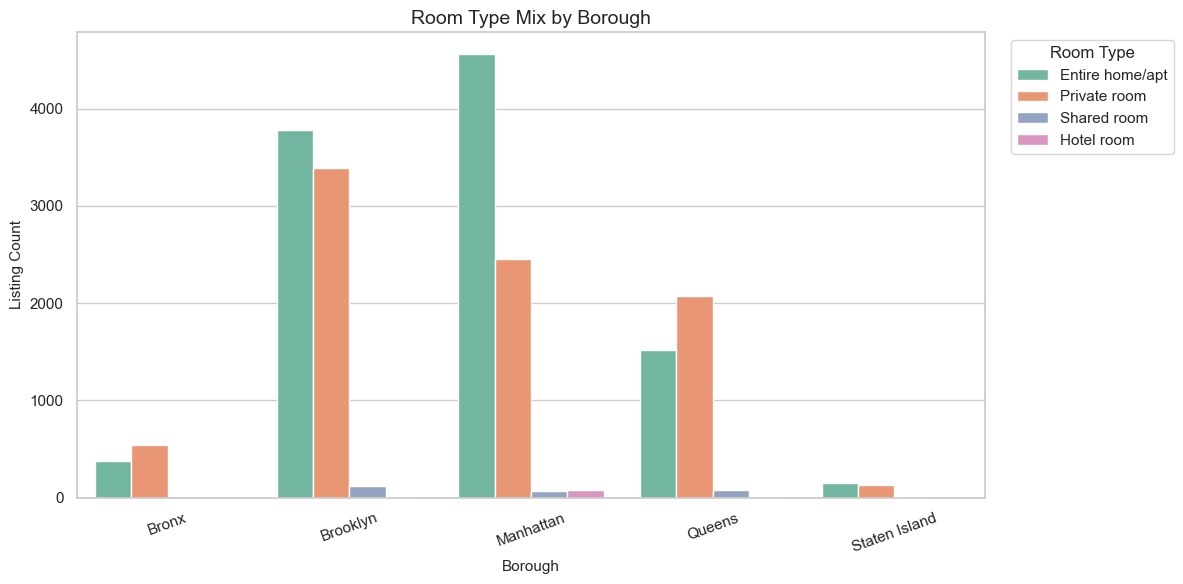

In [14]:
room_supply = (
    focused_df.groupby(['neighbourhood_group', 'room_type'])
      .size()
      .reset_index(name='listing_count')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=room_supply, x='neighbourhood_group', y='listing_count', hue='room_type')
plt.title('Room Type Mix by Borough')
plt.xlabel('Borough')
plt.ylabel('Listing Count')
plt.xticks(rotation=20)
plt.legend(title='Room Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Business Question 2: How does pricing vary by borough and room type?
Median price is used as the primary measure because Airbnb prices are skewed and outlier-sensitive.

In [15]:
price_by_borough = (
    focused_df.groupby('neighbourhood_group')
      .agg(
          listings=('id', 'count'),
          median_price=('price', 'median'),
          avg_price=('price', 'mean'),
          median_price_per_bed=('price_per_bed', 'median') if 'price_per_bed' in focused_df.columns else ('price', 'median')
      )
      .sort_values('median_price', ascending=False)
      .reset_index()
)

price_by_borough

,neighbourhood_group,listings,median_price,avg_price,median_price_per_bed
0,Manhattan,7157,140.00,155.75,100.00
1,Brooklyn,7295,120.00,133.89,77.33
2,Staten Island,286,98.00,110.58,60.00
3,Queens,3670,95.00,112.46,65.00
4,Bronx,934,89.00,102.18,62.50


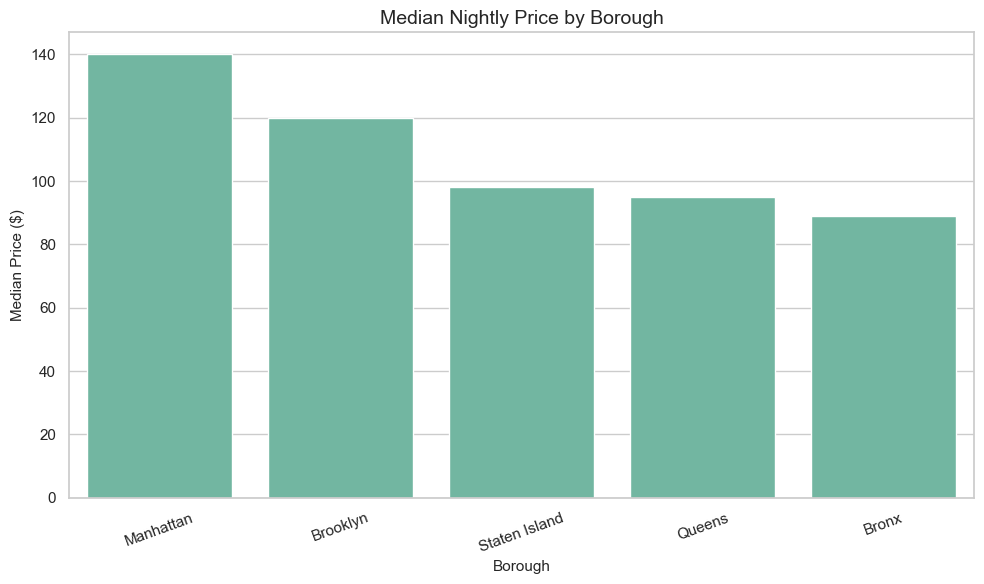

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=price_by_borough, x='neighbourhood_group', y='median_price')
plt.title('Median Nightly Price by Borough')
plt.xlabel('Borough')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

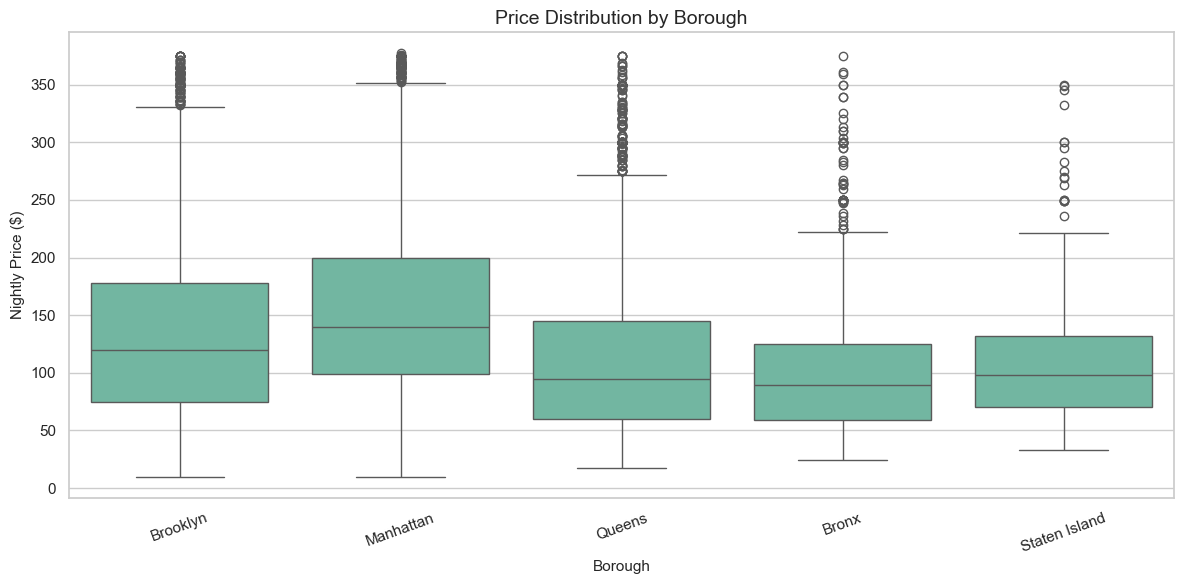

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=focused_df, x='neighbourhood_group', y='price')
plt.title('Price Distribution by Borough')
plt.xlabel('Borough')
plt.ylabel('Nightly Price ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
price_by_room_type = (
    focused_df.groupby(['neighbourhood_group', 'room_type'])
      .agg(listings=('id', 'count'), median_price=('price', 'median'), avg_price=('price', 'mean'))
      .sort_values(['neighbourhood_group', 'median_price'], ascending=[True, False])
      .reset_index()
)

price_by_room_type

,neighbourhood_group,room_type,listings,median_price,avg_price
0,Bronx,Entire home/apt,378,123.50,139.09
1,Bronx,Private room,541,65.00,76.81
2,Bronx,Shared room,15,50.00,87.33
3,Brooklyn,Hotel room,4,172.00,162.75
4,Brooklyn,Entire home/apt,3779,155.00,171.40
5,Brooklyn,Shared room,119,95.00,102.76
6,Brooklyn,Private room,3393,75.00,93.18
7,Manhattan,Hotel room,78,217.00,219.04
8,Manhattan,Entire home/apt,4556,158.50,175.71
9,Manhattan,Private room,2452,100.00,118.27


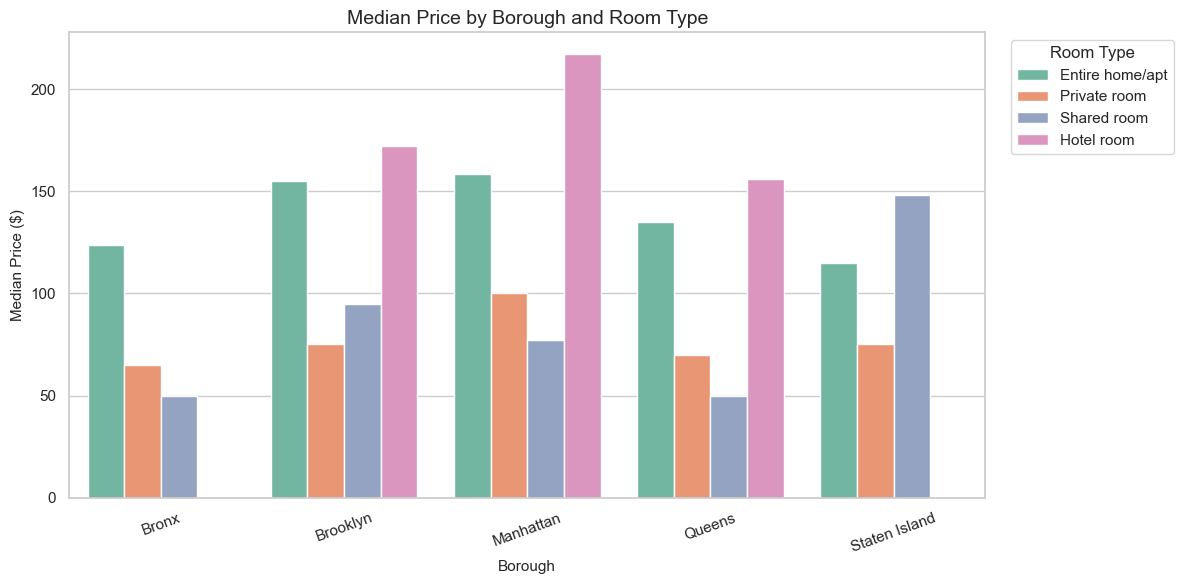

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(data=price_by_room_type, x='neighbourhood_group', y='median_price', hue='room_type')
plt.title('Median Price by Borough and Room Type')
plt.xlabel('Borough')
plt.ylabel('Median Price ($)')
plt.xticks(rotation=20)
plt.legend(title='Room Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 9. Business Question 3: Which neighborhoods have premium pricing?
To avoid misleading conclusions from neighborhoods with very few listings, we only rank neighborhoods with a minimum listing threshold.

In [20]:
MIN_LISTINGS = 50

neighborhood_price = (
    focused_df.groupby(['neighbourhood_group', 'neighbourhood'])
      .agg(
          listings=('id', 'count'),
          median_price=('price', 'median'),
          avg_price=('price', 'mean'),
          median_availability=('availability_365', 'median') if 'availability_365' in focused_df.columns else ('price', 'median')
      )
      .query('listings >= @MIN_LISTINGS')
      .sort_values('median_price', ascending=False)
      .reset_index()
)

neighborhood_price.head(15)

,neighbourhood_group,neighbourhood,listings,median_price,avg_price,median_availability
0,Manhattan,Greenwich Village,69,200.00,209.52,173.00
1,Manhattan,West Village,171,200.00,206.71,127.00
2,Manhattan,SoHo,105,193.00,208.82,177.00
3,Manhattan,Financial District,163,193.00,192.53,173.00
4,Manhattan,Theater District,118,177.00,191.62,281.00
5,Brooklyn,Park Slope,144,172.50,171.47,165.00
6,Manhattan,Chelsea,309,171.00,183.31,242.00
7,Brooklyn,Carroll Gardens,70,169.50,178.41,178.00
8,Brooklyn,Greenpoint,275,162.00,169.27,180.00
9,Manhattan,Midtown,816,162.00,173.59,179.00


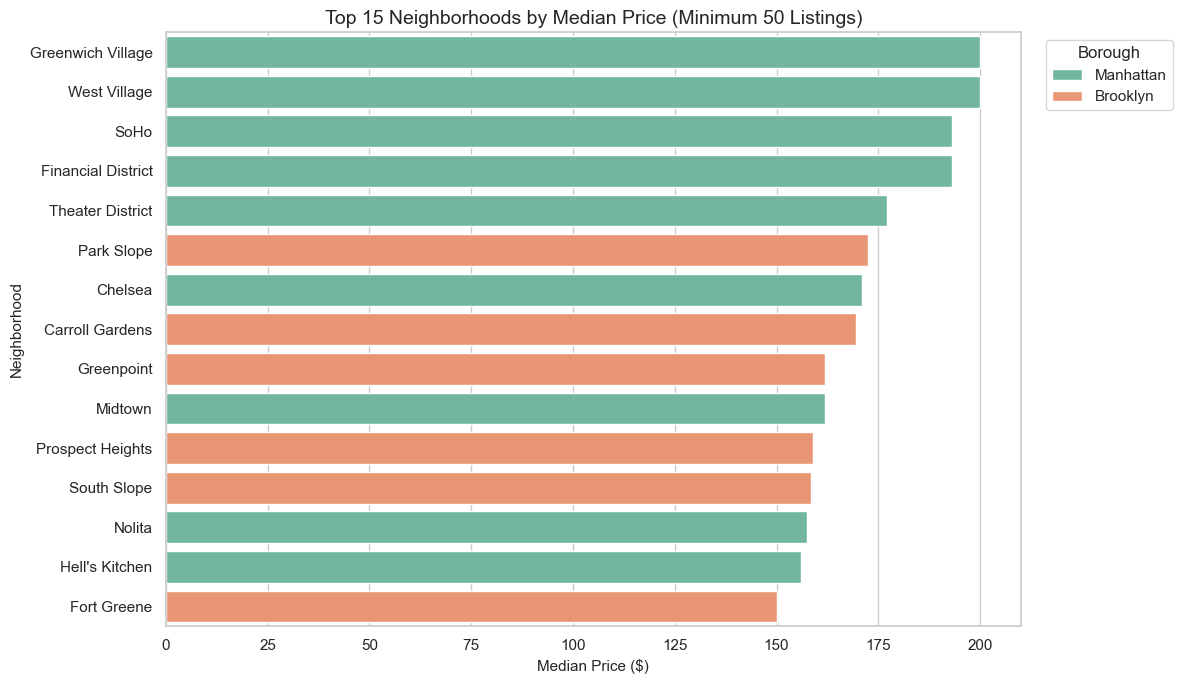

In [21]:
top_neighborhoods = neighborhood_price.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_neighborhoods, y='neighbourhood', x='median_price', hue='neighbourhood_group', dodge=False)
plt.title(f'Top 15 Neighborhoods by Median Price (Minimum {MIN_LISTINGS} Listings)')
plt.xlabel('Median Price ($)')
plt.ylabel('Neighborhood')
plt.legend(title='Borough', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 10. Business Question 4: How do availability and stay policies affect the market?
Availability can indicate supply readiness. Minimum-night rules can affect guest accessibility and booking conversion.

In [22]:
availability_summary = (
    focused_df.groupby('availability_bucket')
      .agg(listings=('id', 'count'), median_price=('price', 'median'))
      .reset_index()
)

availability_summary['listing_share_pct'] = (availability_summary['listings'] / availability_summary['listings'].sum() * 100).round(2)
availability_summary

,availability_bucket,listings,median_price,listing_share_pct
0,Unavailable,2328,120.00,12.04
1,Low availability,3651,110.00,18.88
2,Medium availability,3250,120.00,16.80
3,High availability,10113,120.00,52.29


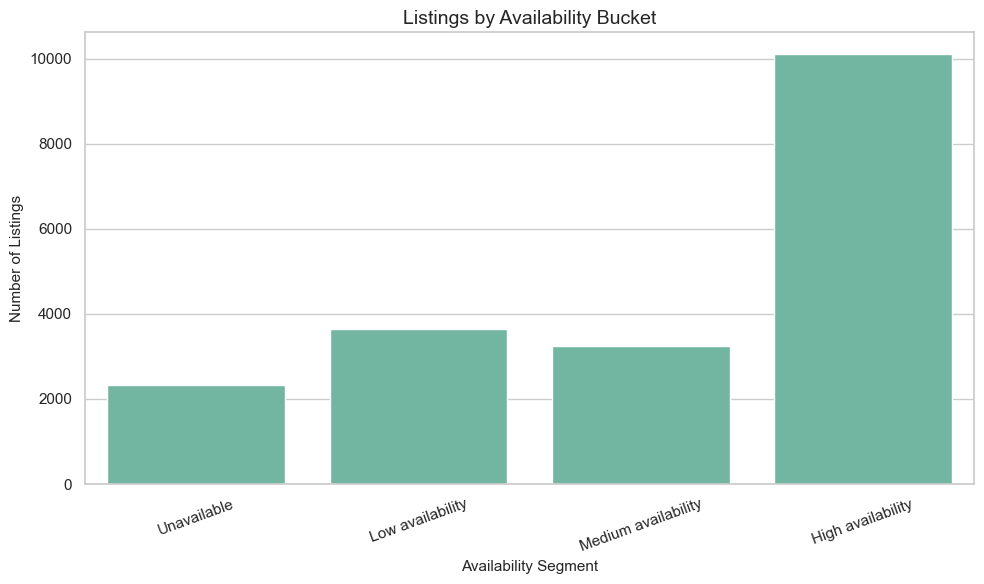

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=focused_df, x='availability_bucket', order=['Unavailable', 'Low availability', 'Medium availability', 'High availability'])
plt.title('Listings by Availability Bucket')
plt.xlabel('Availability Segment')
plt.ylabel('Number of Listings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [24]:
stay_policy_summary = (
    focused_df.groupby('stay_policy')
      .agg(listings=('id', 'count'), median_price=('price', 'median'))
      .reset_index()
)

stay_policy_summary['listing_share_pct'] = (stay_policy_summary['listings'] / stay_policy_summary['listings'].sum() * 100).round(2)
stay_policy_summary

,stay_policy,listings,median_price,listing_share_pct
0,Short stay friendly,1947,153.00,10.07
1,Weekly stay,716,170.00,3.70
2,Monthly stay,15909,111.00,82.25
3,Long-term only,770,125.00,3.98


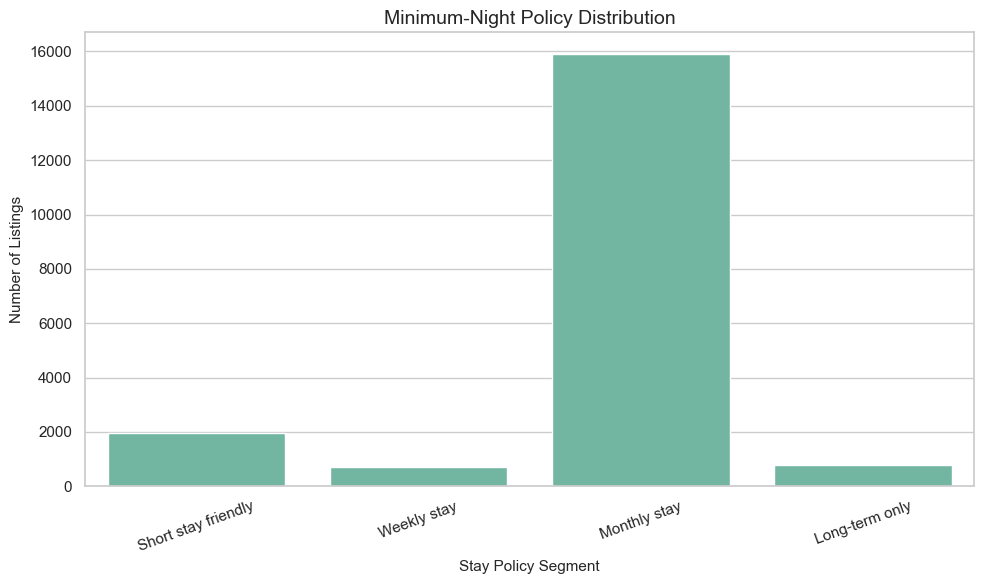

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=focused_df, x='stay_policy', order=['Short stay friendly', 'Weekly stay', 'Monthly stay', 'Long-term only'])
plt.title('Minimum-Night Policy Distribution')
plt.xlabel('Stay Policy Segment')
plt.ylabel('Number of Listings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 11. Business Question 5: What demand signals appear in reviews?
Reviews are not a perfect demand measure, but review count, reviews per month, and recent review activity are useful engagement signals.

In [26]:
review_summary = (
    focused_df.groupby(['neighbourhood_group', 'room_type'])
      .agg(
          listings=('id', 'count'),
          avg_reviews=('number_of_reviews', 'mean'),
          median_reviews=('number_of_reviews', 'median'),
          avg_reviews_per_month=('reviews_per_month', 'mean'),
          median_price=('price', 'median')
      )
      .sort_values('avg_reviews_per_month', ascending=False)
      .reset_index()
)

review_summary

,neighbourhood_group,room_type,listings,avg_reviews,median_reviews,avg_reviews_per_month,median_price
0,Staten Island,Shared room,4,24.50,24.00,2.16,148.00
1,Queens,Shared room,75,51.89,19.00,1.66,50.00
2,Bronx,Shared room,15,49.73,26.00,1.63,50.00
3,Manhattan,Private room,2452,51.58,15.00,1.54,100.00
4,Queens,Entire home/apt,1513,45.33,23.00,1.53,135.00
5,Staten Island,Entire home/apt,152,46.59,27.00,1.50,115.00
6,Manhattan,Hotel room,78,69.31,10.00,1.47,217.00
7,Queens,Private room,2075,42.70,17.00,1.43,70.00
8,Staten Island,Private room,130,46.73,19.00,1.43,75.00
9,Bronx,Entire home/apt,378,39.29,19.50,1.37,123.50


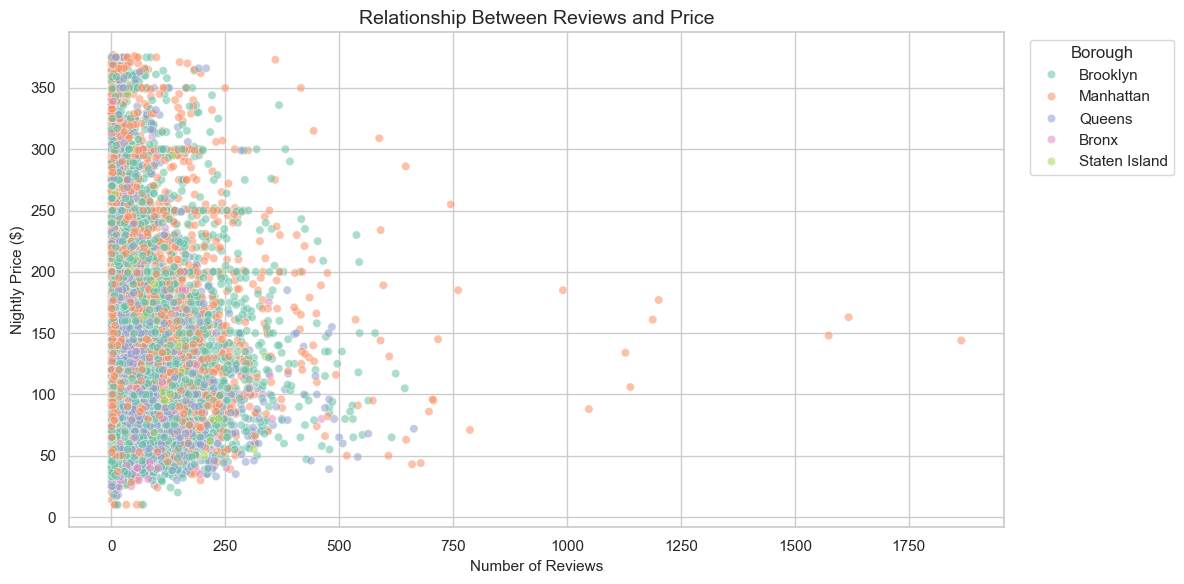

In [27]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=focused_df,
    x='number_of_reviews',
    y='price',
    hue='neighbourhood_group',
    alpha=0.55
)
plt.title('Relationship Between Reviews and Price')
plt.xlabel('Number of Reviews')
plt.ylabel('Nightly Price ($)')
plt.legend(title='Borough', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

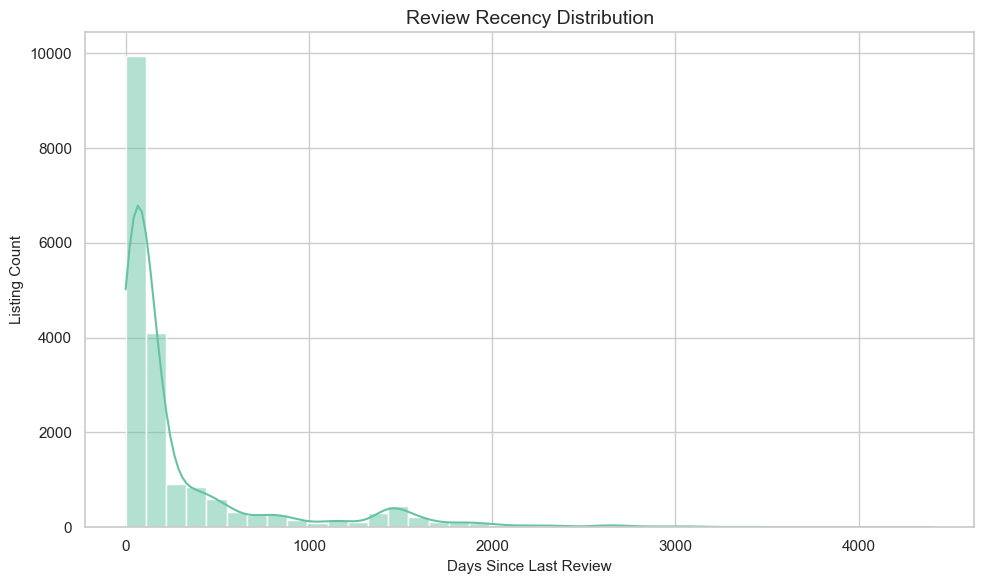

In [28]:
if 'review_recency_days' in focused_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=focused_df, x='review_recency_days', bins=40, kde=True)
    plt.title('Review Recency Distribution')
    plt.xlabel('Days Since Last Review')
    plt.ylabel('Listing Count')
    plt.tight_layout()
    plt.show()

## 12. Business Question 6: Are listings driven by individual or professional hosts?
Host concentration helps identify whether the market is dominated by individual hosts or larger operators.

In [29]:
host_portfolio_summary = (
    focused_df.groupby('host_portfolio_type')
      .agg(
          listings=('id', 'count'),
          unique_hosts=('host_id', 'nunique'),
          median_price=('price', 'median'),
          median_availability=('availability_365', 'median') if 'availability_365' in focused_df.columns else ('price', 'median')
      )
      .reset_index()
)

host_portfolio_summary['listing_share_pct'] = (host_portfolio_summary['listings'] / host_portfolio_summary['listings'].sum() * 100).round(2)
host_portfolio_summary

,host_portfolio_type,listings,unique_hosts,median_price,median_availability,listing_share_pct
0,Single-listing host,8354,8354,135.00,177.00,43.19
1,Small portfolio host,6144,2815,102.00,233.00,31.77
2,Medium portfolio host,2488,381,102.00,269.00,12.86
3,Large portfolio host,2356,70,117.00,281.00,12.18


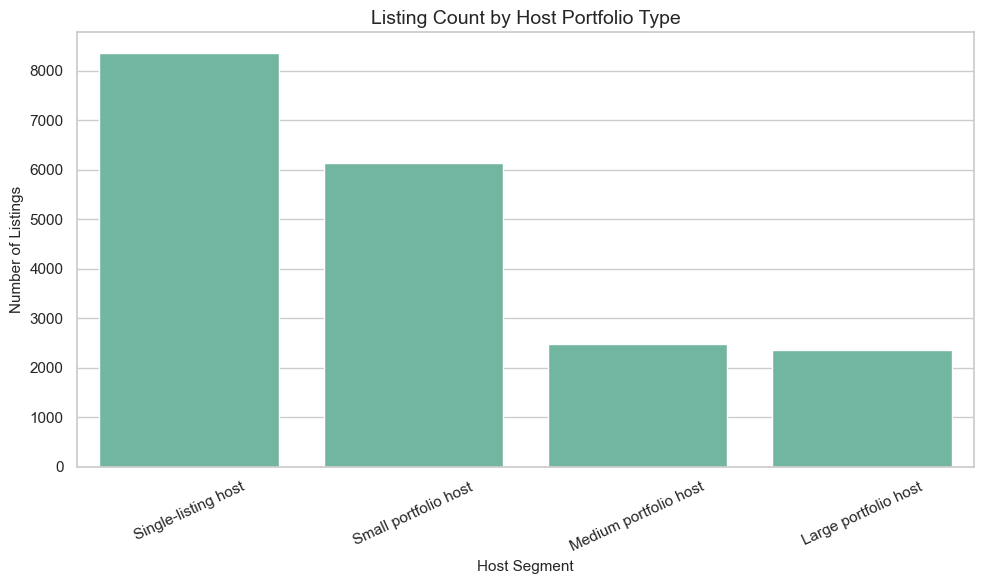

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(data=host_portfolio_summary, x='host_portfolio_type', y='listings')
plt.title('Listing Count by Host Portfolio Type')
plt.xlabel('Host Segment')
plt.ylabel('Number of Listings')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [31]:
top_hosts = (
    focused_df.groupby(['host_id', 'host_name'])
      .agg(
          listings=('id', 'count'),
          median_price=('price', 'median'),
          avg_availability=('availability_365', 'mean') if 'availability_365' in focused_df.columns else ('price', 'mean')
      )
      .sort_values('listings', ascending=False)
      .head(10)
      .reset_index()
)

top_hosts

,host_id,host_name,listings,median_price,avg_availability
0,162280872,Urban Furnished,146,139.00,314.85
1,51501835,Jeniffer,129,120.00,303.61
2,61391963,Stay With Vibe,113,99.00,295.56
3,107434423,Blueground,96,266.00,288.29
4,19303369,Hiroki,87,38.00,48.07
5,137358866,Kaz,80,41.00,319.38
6,219517861,Sonder (NYC),71,193.00,129.28
7,200239515,Shogo,70,38.00,45.74
8,120762452,Stanley,69,120.00,341.61
9,204704622,Momoyo,61,36.00,43.82


## 13. Business Question 7: Where are listings geographically clustered?
The longitude and latitude plot helps identify spatial clustering and borough-level pricing patterns.

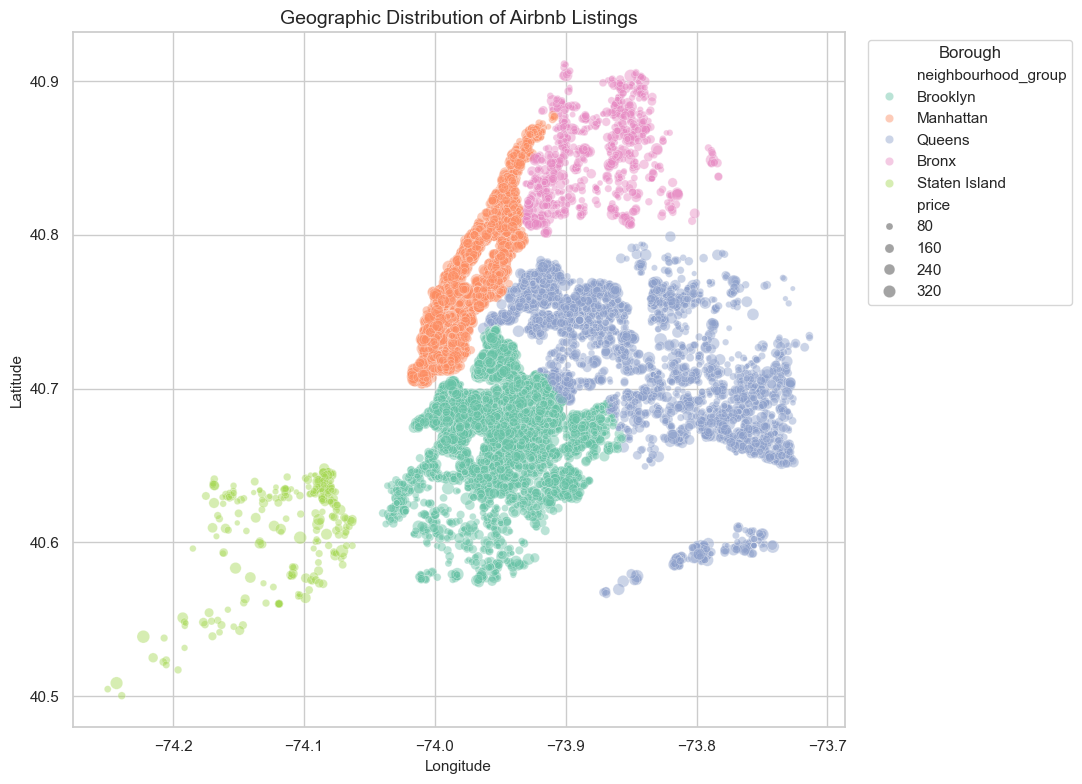

In [32]:
plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=focused_df,
    x='longitude',
    y='latitude',
    hue='neighbourhood_group',
    size='price',
    sizes=(10, 90),
    alpha=0.45
)
plt.title('Geographic Distribution of Airbnb Listings')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Borough', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 14. Correlation Analysis
Correlation does not prove causation, but it helps identify relationships worth investigating further.

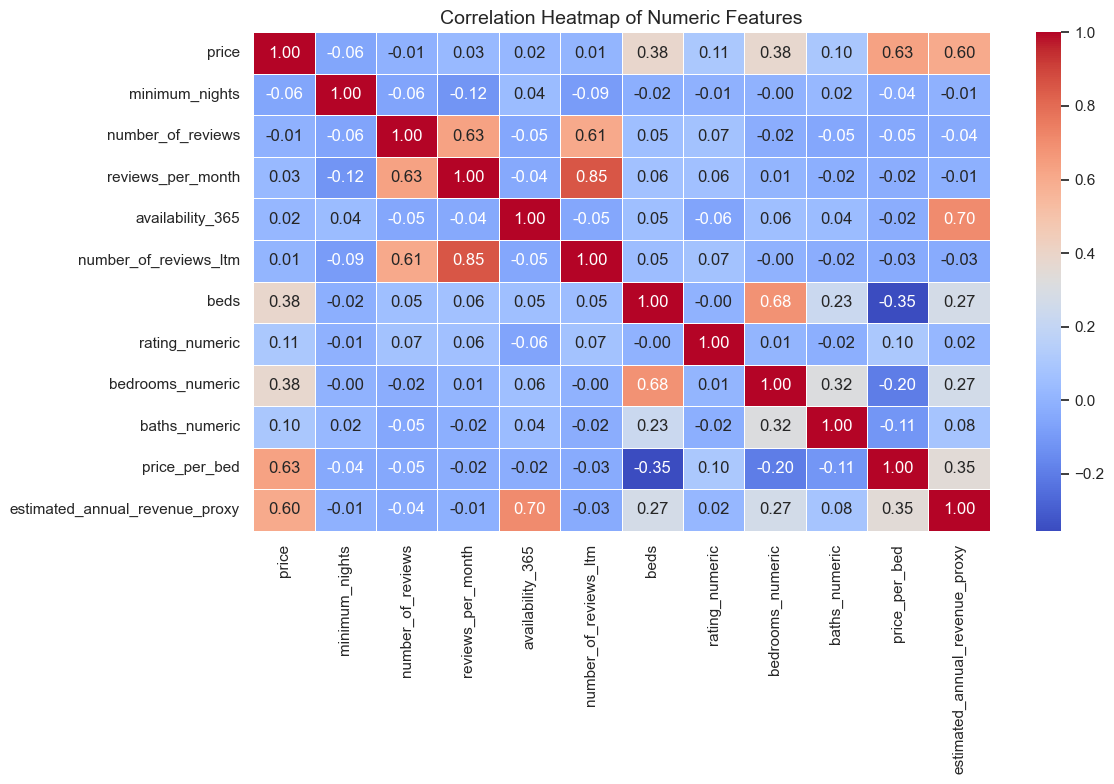

In [33]:
corr_cols = [
    'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
    'availability_365', 'number_of_reviews_ltm', 'beds', 'rating_numeric',
    'bedrooms_numeric', 'baths_numeric', 'price_per_bed', 'estimated_annual_revenue_proxy'
]
existing_corr_cols = [col for col in corr_cols if col in focused_df.columns]

corr_matrix = focused_df[existing_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## 15. Opportunity Analysis: Price vs Availability
This view helps classify listings into opportunity segments. High-price and high-availability listings may represent strong revenue potential, while high-availability and low-price listings may indicate underpriced or low-demand inventory.

In [34]:
if {'price', 'availability_365'}.issubset(focused_df.columns):
    price_median = focused_df['price'].median()
    availability_median = focused_df['availability_365'].median()

    def opportunity_segment(row):
        if row['price'] >= price_median and row['availability_365'] >= availability_median:
            return 'High price / High availability'
        elif row['price'] >= price_median and row['availability_365'] < availability_median:
            return 'High price / Low availability'
        elif row['price'] < price_median and row['availability_365'] >= availability_median:
            return 'Low price / High availability'
        else:
            return 'Low price / Low availability'

    focused_df['opportunity_segment'] = focused_df.apply(opportunity_segment, axis=1)

    opportunity_summary = (
        focused_df.groupby('opportunity_segment')
          .agg(
              listings=('id', 'count'),
              median_price=('price', 'median'),
              median_availability=('availability_365', 'median'),
              median_revenue_proxy=('estimated_annual_revenue_proxy', 'median')
          )
          .sort_values('median_revenue_proxy', ascending=False)
          .reset_index()
    )

    opportunity_summary

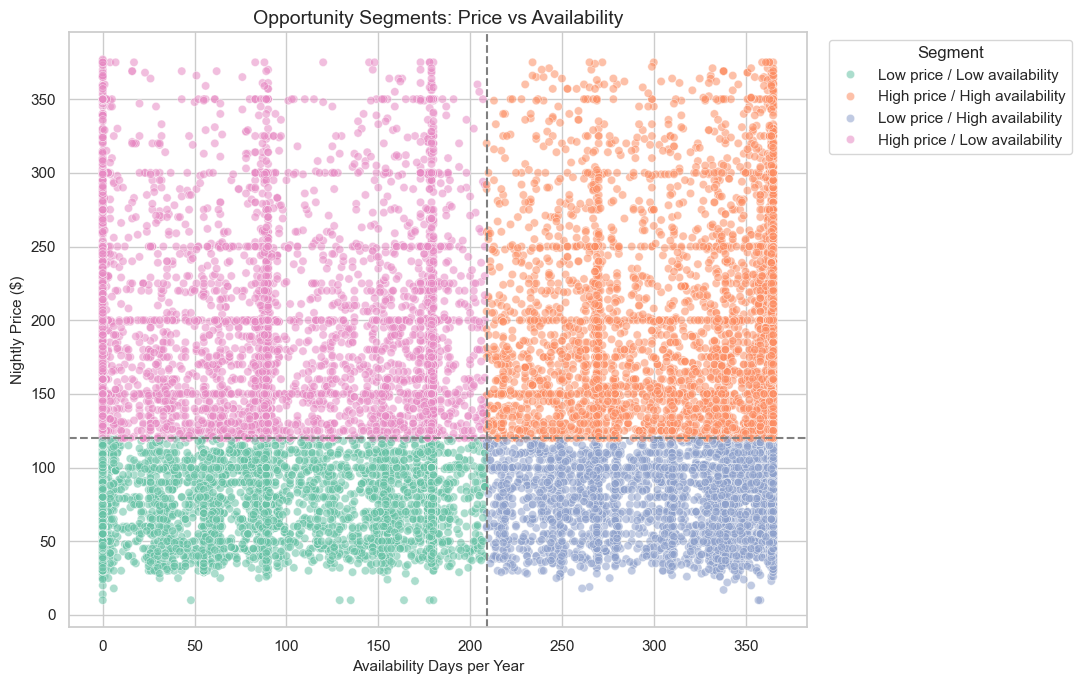

In [35]:
if 'opportunity_segment' in focused_df.columns:
    plt.figure(figsize=(11, 7))
    sns.scatterplot(
        data=focused_df,
        x='availability_365',
        y='price',
        hue='opportunity_segment',
        alpha=0.55
    )
    plt.axhline(focused_df['price'].median(), linestyle='--', color='gray')
    plt.axvline(focused_df['availability_365'].median(), linestyle='--', color='gray')
    plt.title('Opportunity Segments: Price vs Availability')
    plt.xlabel('Availability Days per Year')
    plt.ylabel('Nightly Price ($)')
    plt.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 16. Dynamic Executive Summary
This cell generates business-friendly insight bullets from the latest run of the notebook. Use these in your README, project report, or portfolio website.

In [36]:
summary_lines = []

# Top borough by supply
top_supply_borough = borough_supply.iloc[0]
summary_lines.append(
    f"- {top_supply_borough['neighbourhood_group']} has the highest listing supply with "
    f"{top_supply_borough['listing_count']:,} listings ({top_supply_borough['listing_share_pct']}% of focused listings)."
)

# Highest median price borough
top_price_borough = price_by_borough.iloc[0]
summary_lines.append(
    f"- {top_price_borough['neighbourhood_group']} has the highest median nightly price at "
    f"${top_price_borough['median_price']:,.0f}."
)

# Highest priced neighborhood
if not neighborhood_price.empty:
    top_neighborhood = neighborhood_price.iloc[0]
    summary_lines.append(
        f"- {top_neighborhood['neighbourhood']} in {top_neighborhood['neighbourhood_group']} is the top premium neighborhood "
        f"among areas with at least {MIN_LISTINGS} listings, with a median price of ${top_neighborhood['median_price']:,.0f}."
    )

# Dominant room type
room_type_counts = focused_df['room_type'].value_counts()
dominant_room = room_type_counts.index[0]
summary_lines.append(
    f"- {dominant_room} is the most common room type, representing {room_type_counts.iloc[0] / len(focused_df) * 100:.1f}% of focused listings."
)

# Host segment
if 'host_portfolio_summary' in globals():
    top_host_segment = host_portfolio_summary.sort_values('listings', ascending=False).iloc[0]
    summary_lines.append(
        f"- {top_host_segment['host_portfolio_type']} accounts for the largest listing share at "
        f"{top_host_segment['listing_share_pct']}%."
    )

print('Executive Summary')
print('\n'.join(summary_lines))

Executive Summary
- Brooklyn has the highest listing supply with 7,295 listings (37.72% of focused listings).
- Manhattan has the highest median nightly price at $140.
- Greenwich Village in Manhattan is the top premium neighborhood among areas with at least 50 listings, with a median price of $200.
- Entire home/apt is the most common room type, representing 53.7% of focused listings.
- Single-listing host accounts for the largest listing share at 43.19%.


## 17. Export Cleaned Data and Summary Tables
Exporting outputs makes the project more reproducible and easier to review in GitHub.

In [37]:
# Save cleaned/focused data and key summary tables
focused_df.to_csv(OUTPUT_DIR / 'airbnb_cleaned_focused_dataset.csv', index=False)
borough_supply.to_csv(OUTPUT_DIR / 'borough_supply_summary.csv', index=False)
price_by_borough.to_csv(OUTPUT_DIR / 'price_by_borough_summary.csv', index=False)
price_by_room_type.to_csv(OUTPUT_DIR / 'price_by_room_type_summary.csv', index=False)
neighborhood_price.to_csv(OUTPUT_DIR / 'neighborhood_price_summary.csv', index=False)

print(f'Exported files to: {OUTPUT_DIR.resolve()}')

Exported files to: C:\Users\venka\Documents\Prep\EDA in python\Airbnb_EDA\outputs


## Final Recommendations
Based on the EDA workflow, the business should focus on:

1. **Pricing Optimization:** Use borough, neighborhood, room type, and bed count as key pricing benchmarks.
2. **Supply Strategy:** Monitor boroughs with high listing density where competition may pressure price.
3. **Premium Market Targeting:** Identify neighborhoods with consistently high median prices and strong review activity.
4. **Host Segmentation:** Separate individual hosts from larger portfolio hosts when designing marketplace strategy.
5. **Demand Monitoring:** Use review frequency and recent reviews as directional demand signals.
6. **Availability Management:** Investigate listings with high availability but low price for potential underperformance or repositioning.

## Limitations
- Review counts are only a proxy for demand because not every guest leaves a review.
- Estimated revenue is a proxy and does not represent actual booked revenue.
- Price outliers were excluded from focused visual analysis, but retained in the cleaned base dataset for auditability.
- This is exploratory analysis, not causal modeling.